In [1]:
import pandas as pd
import numpy as np

# Read the clean and unified data from the first stage
df = pd.read_csv("updated16_file.csv")

# Ensure data readiness and check size
print(f"✅ Data loaded successfully! Current table size: {df.shape}")
df.head()

✅ Data loaded successfully! Current table size: (10000, 22)


,id,supplier_id,invoice_id,prod_id,product_name,quantity,discount,total_amount,account_id,account_name,...,user_name,employee_name,city,region,area,area_id,creation_date,created_at,branch_code,Global_Account_ID
0,48652728,59,32259,7,سيبروسين مرهم س ج,10,15.0,178.50,637,صيدليه مها مديريه امن الجيزه ش,...,نهى الدالى,نهى الدالى,الجيزة,القاهرة الكبرى,الجيزة,17.0,2025-05-25 13:43:10,2026-05-19 16:29:03,3.0,GLB_0001
1,48652935,59,32281,7,سيبروسين مرهم س ج,3,15.0,53.55,4365,صيدليه السعدني فيصل,...,نهى الدالى,نهى الدالى,الجيزة,القاهرة الكبرى,فيصل,99.0,2025-05-25 14:35:04,2026-05-19 16:29:03,2.0,GLB_0002
2,48653089,59,32301,7,سيبروسين مرهم س ج,2,21.0,33.18,3297,صيدليه مني احمد امبابه,...,اسماء رجب,اسماء رجب,الجيزة,القاهرة الكبرى,إمبابة,9.0,2025-05-25 15:21:21,2026-05-19 16:29:03,4.0,GLB_0003
3,48653301,59,32334,7,سيبروسين مرهم س ج,5,20.0,84.00,5734,صيدليه الشفاء بشتيل,...,اسماء رجب,اسماء رجب,الجيزة,القاهرة الكبرى,بشتيل,69.0,2025-05-25 20:49:54,2026-05-19 16:29:03,4.0,GLB_0004
4,49140754,59,100804,7,سيبروسين مرهم س ج,10,17.0,174.30,637,صيدليه مها مديريه امن الجيزه ش,...,نهى الدالى,نهى الدالى,الجيزة,القاهرة الكبرى,الجيزة,17.0,2026-04-12 13:51:32,2026-05-19 16:47:49,3.0,GLB_0001


In [2]:
# --- 2.2 Verify Invoice Key Integrity and Clean Outliers ---

# 1. Check that each invoice (supplier + invoice number) belongs to only one pharmacy
invoice_pharmacy_check = df.groupby(['supplier_id', 'invoice_id'])['Global_Account_ID'].nunique()
invalid_invoices = invoice_pharmacy_check[invoice_pharmacy_check > 1]
print(f"⚠️ Number of invoices erroneously linked to more than one pharmacy: {len(invalid_invoices)}")
# If the result is not zero, these invoices can be removed or corrected, 
# but usually, after the unification performed earlier, it should be zero.

# 2. Filter out returned or zero-value invoices (e.g., invoices with 0 or negative amounts)
rows_before = len(df)
df_clean = df[df['total_amount'] > 0].copy()
rows_after = len(df_clean)
print(f"🧹 Cleaned {rows_before - rows_after} rows (junk data/returns with zero or negative value).")
print("-" * 50)


# --- 2.1 Build Invoice-level Table ---

# Aggregate data so that each row represents a single invoice
invoice_level = df_clean.groupby(['supplier_id', 'invoice_id']).agg(
    Global_Account_ID=('Global_Account_ID', 'first'),
    account_name=('account_name', 'first'),      # Kept name for readability
    invoice_date=('creation_date', 'first'),
    total_invoice_amount=('total_amount', 'sum'), # Total invoice value
    total_quantity=('quantity', 'sum'),          # Total number of packs/quantities
    distinct_products=('prod_id', 'nunique')      # Number of distinct products in the invoice
).reset_index()

# Convert the date column to Datetime format to facilitate future calculations (first/last transaction)
invoice_level['invoice_date'] = pd.to_datetime(invoice_level['invoice_date'], errors='coerce')

print("🧾 Invoice-level Table - First 5 invoices:")
display(invoice_level.head())
print("-" * 50)


# --- 2.3 Calculate Pharmacy Revenue Rollup ---

# Aggregate the invoice table at the pharmacy level
pharmacy_rollup = invoice_level.groupby(['Global_Account_ID', 'account_name']).agg(
    total_revenue=('total_invoice_amount', 'sum'),       # Total revenue
    invoice_count=('invoice_id', 'nunique'),             # Number of invoices
    avg_invoice_value=('total_invoice_amount', 'mean'),  # Average invoice value
    first_transaction=('invoice_date', 'min'),           # Date of first transaction
    last_transaction=('invoice_date', 'max')             # Date of last transaction
).reset_index()

# Sort pharmacies by revenue (highest to lowest)
pharmacy_rollup = pharmacy_rollup.sort_values('total_revenue', ascending=False)

print("🏆 Pharmacy Revenue Rollup - Top 5 pharmacies:")
display(pharmacy_rollup.head())

⚠️ Number of invoices erroneously linked to more than one pharmacy: 0
🧹 Cleaned 1 rows (junk data/returns with zero or negative value).
--------------------------------------------------
🧾 Invoice-level Table - First 5 invoices:


,supplier_id,invoice_id,Global_Account_ID,account_name,invoice_date,total_invoice_amount,total_quantity,distinct_products
0,59,330,GLB_0038,صيدليه د مروه الرحاب,2025-01-02 16:16:02,67.50,6,1
1,59,461,GLB_0039,صيدليه محمود مصطفي الهرم,2025-01-03 12:12:54,21.30,2,1
2,59,1153,GLB_0100,صيدليه فارما سي مارت الجيزه,2025-01-07 10:22:12,21.00,3,1
3,59,1675,GLB_0040,صيدليه رباب الوحده امبابه,2025-01-09 23:24:33,21.30,2,1
4,59,1695,GLB_0041,صيدليه احمد عماد فيصل,2025-01-09 00:59:59,53.25,5,1


--------------------------------------------------
🏆 Pharmacy Revenue Rollup - Top 5 pharmacies:


,Global_Account_ID,account_name,total_revenue,invoice_count,avg_invoice_value,first_transaction,last_transaction
1086,GLB_1087,فارم احمد عبدالله المنصوره,372736.00,2,186368.000000,2026-01-25 18:28:29,2026-02-12 08:33:49
364,GLB_0365,صيدليه ياسر فتحي فيصل توصيل م س,250230.96,176,1421.766818,2025-09-20 13:52:02,2026-02-11 14:15:18
1074,GLB_1075,عميل مخزن الجمله,228749.77,2,114374.885000,2024-07-01 17:39:51,2024-07-16 12:24:47
1026,GLB_1027,مخزن الامراء,120148.28,9,13349.808889,2026-04-11 12:46:39,2026-05-19 17:25:02
1091,GLB_1092,الاصدقاء العريش,98742.45,22,4488.293182,2026-01-04 10:20:08,2026-02-09 10:05:58


In [3]:
# 1. Extract invoices whose value equals the anomalous figure
suspicious_amount = 372736.00
anomaly_invoices = invoice_level[invoice_level['total_invoice_amount'] == suspicious_amount]

print("🚨 Suspicious invoices from the summary table:")
display(anomaly_invoices)
print("-" * 50)

# 2. Inspect the contents of these invoices item by item from the base data
suspicious_invoice_ids = anomaly_invoices['invoice_id'].tolist()
anomaly_details = df_clean[df_clean['invoice_id'].isin(suspicious_invoice_ids)][
    ['invoice_id', 'prod_id', 'product_name', 'quantity', 'total_amount', 'creation_date']
].sort_values(by=['prod_id', 'invoice_id'])

print("📦 Details of items within these invoices:")
display(anomaly_details)

🚨 Suspicious invoices from the summary table:


,supplier_id,invoice_id,Global_Account_ID,account_name,invoice_date,total_invoice_amount,total_quantity,distinct_products


--------------------------------------------------
📦 Details of items within these invoices:


,invoice_id,prod_id,product_name,quantity,total_amount,creation_date


In [4]:
# 1. Identify anomalous invoices (double entries) based on matching criteria 
# (Supplier, Pharmacy, Product, Quantity, and Price)
# We consider it a duplicate error if the same product is entered for the same pharmacy 
# with the same quantity and price on the same day
duplicates_mask = df_clean.duplicated(
    subset=['supplier_id', 'Global_Account_ID', 'prod_id', 'quantity', 'total_amount'], 
    keep=False # Keep all duplicate copies to inspect them
)

# 2. Anomalies table (we save this to showcase as an achievement in the report)
anomalies_df = df_clean[duplicates_mask].sort_values(by=['Global_Account_ID', 'prod_id'])

print(f"🚨 Detected {len(anomalies_df)} duplicate rows (Double Entries) representing unusual patterns!")
display(anomalies_df.head())

🚨 Detected 943 duplicate rows (Double Entries) representing unusual patterns!


,id,supplier_id,invoice_id,prod_id,product_name,quantity,discount,total_amount,account_id,account_name,...,user_name,employee_name,city,region,area,area_id,creation_date,created_at,branch_code,Global_Account_ID
173,48694760,59,38233,26,تيراميسين مرهم للعين س ج,10,4.0,268.8,637,صيدليه مها مديريه امن الجيزه ش,...,نهى الدالى,نهى الدالى,الجيزة,القاهرة الكبرى,الجيزة,17.0,2025-06-18 11:25:10,2026-05-19 16:30:35,3.0,GLB_0001
193,48708080,59,40128,26,تيراميسين مرهم للعين س ج,10,4.0,268.8,637,صيدليه مها مديريه امن الجيزه ش,...,نهى الدالى,نهى الدالى,الجيزة,القاهرة الكبرى,الجيزة,17.0,2025-06-25 20:54:04,2026-05-19 16:30:57,3.0,GLB_0001
222,48722427,59,42153,26,تيراميسين مرهم للعين س ج,10,4.0,268.8,637,صيدليه مها مديريه امن الجيزه ش,...,نهى الدالى,نهى الدالى,الجيزة,القاهرة الكبرى,الجيزة,17.0,2025-07-03 20:46:40,2026-05-19 16:31:28,3.0,GLB_0001
242,48732585,59,43525,26,تيراميسين مرهم للعين س ج,10,4.0,268.8,637,صيدليه مها مديريه امن الجيزه ش,...,نهى الدالى,نهى الدالى,الجيزة,القاهرة الكبرى,الجيزة,17.0,2025-07-08 20:17:44,2026-05-19 16:31:45,3.0,GLB_0001
251,48734602,59,43857,26,تيراميسين مرهم للعين س ج,10,4.0,268.8,637,صيدليه مها مديريه امن الجيزه ش,...,نهى الدالى,نهى الدالى,الجيزة,القاهرة الكبرى,الجيزة,17.0,2025-07-09 21:59:31,2026-05-19 16:31:55,3.0,GLB_0001


In [5]:
# Remove duplicates while keeping only one copy (keep='first')
rows_before_dedup = len(df_clean)
df_clean = df_clean.drop_duplicates(
    subset=['supplier_id', 'Global_Account_ID', 'prod_id', 'quantity', 'total_amount'], 
    keep='first'
)
rows_after_dedup = len(df_clean)

print(f"🧹 Cleaned {rows_before_dedup - rows_after_dedup} erroneously duplicated rows.")

# ⚠️ Very important: Since we have cleaned the base data, we must re-run the code 
# that builds the invoice-level table (invoice_level) and the pharmacy revenue 
# rollup code (pharmacy_rollup) that we performed in the previous step so that 
# the numbers are updated.

🧹 Cleaned 522 erroneously duplicated rows.


C:\Users\Ahmed\AppData\Local\Temp\ipykernel_20352\3016747867.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_pharmacies, x='total_amount', y=labels, palette='viridis') # لاحظ استخدمنا labels هنا
c:\Users\Ahmed\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


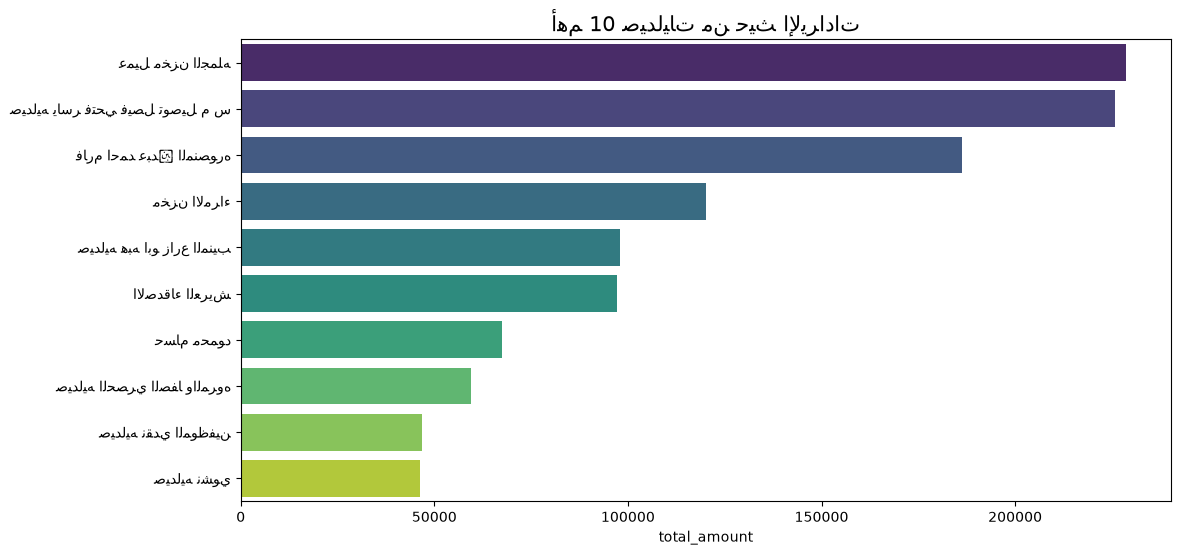

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. تجهيز الداتا للتحليل (Pharmacy + Supplier Breakdown)
# بنجمع الإيرادات على مستوى الصيدلية والمورد
pharmacy_supplier_analysis = df_clean.groupby(['Global_Account_ID', 'account_name', 'supplier_id'])['total_amount'].sum().reset_index()

# 2. جراف (1): أهم 10 صيدليات من حيث الإيرادات الكلية
top_10_pharmacies = pharmacy_supplier_analysis.groupby(['Global_Account_ID', 'account_name'])['total_amount'].sum().nlargest(10).reset_index()

import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display

# دالة مساعدة لضبط النص العربي
def fix_arabic_text(text):
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)
    return bidi_text

# مثال على كيفية استخدامه في الـ Bar Chart:
labels = [fix_arabic_text(name) for name in top_10_pharmacies['account_name']]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_pharmacies, x='total_amount', y=labels, palette='viridis') # لاحظ استخدمنا labels هنا
plt.title(fix_arabic_text('أهم 10 صيدليات من حيث الإيرادات'), fontsize=15)
plt.show()

c:\Users\Ahmed\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65010 (\N{ARABIC LIGATURE ALLAH ISOLATED FORM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


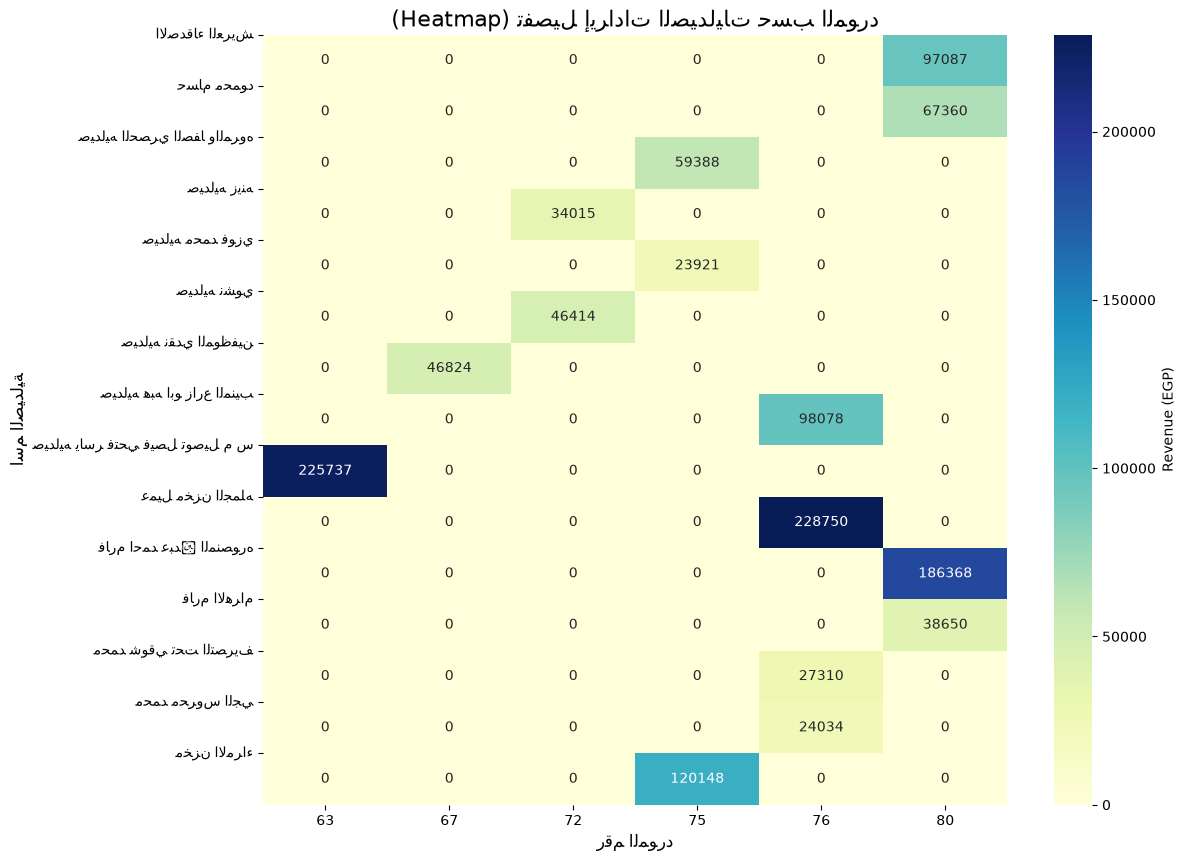

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

top_pharmacies_ids = pharmacy_supplier_analysis.groupby('Global_Account_ID')['total_amount'].sum().nlargest(15).index
subset_df = pharmacy_supplier_analysis[pharmacy_supplier_analysis['Global_Account_ID'].isin(top_pharmacies_ids)]

pivot_df = subset_df.pivot(index='account_name', columns='supplier_id', values='total_amount').fillna(0)

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_df, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Revenue (EGP)'})

plt.title(fix_arabic_text('تفصيل إيرادات الصيدليات حسب المورد (Heatmap)'), fontsize=16)
plt.xlabel(fix_arabic_text('رقم المورد'), fontsize=12)
plt.ylabel(fix_arabic_text('اسم الصيدلية'), fontsize=12)

y_labels = [fix_arabic_text(name) for name in pivot_df.index]
plt.yticks(ticks=range(len(y_labels)), labels=y_labels, rotation=0)

plt.show()